In [11]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("../results/original/forgetting_results.json") as f:
    data = json.load(f)

s = data["summary"]

In [14]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# Load results
# -----------------------------
RESULT_PATH = "../results/original/forgetting_results.json"   # change if needed

with open(RESULT_PATH, "r") as f:
    results = json.load(f)

summary = results["summary"]
per_seed = results["per_seed"]
config = results["config"]

print("Config:")
for k, v in config.items():
    print(f"  {k}: {v}")

print("\nClasses:")
print("  image A class:", results["image_a_class"])
print("  image B class:", results["image_b_class"])

print("\nMain summary:")
print(f"  steps_to_memorize_a_mean = {summary['steps_to_memorize_a_mean']:.3f} ± {summary['steps_to_memorize_a_std']:.3f}")
print(f"  steps_to_memorize_b_mean = {summary['steps_to_memorize_b_mean']:.3f} ± {summary['steps_to_memorize_b_std']:.3f}")
print(f"  both_correct_during_B_mean = {summary['n_steps_both_correct_during_B_mean']:.3f} ± {summary['n_steps_both_correct_during_B_std']:.3f}")
print(f"  both_margin_positive_during_B_mean = {summary['n_steps_both_margin_positive_during_B_mean']:.3f} ± {summary['n_steps_both_margin_positive_during_B_std']:.3f}")

Config:
  threshold: 2.5
  learning_rate: 0.2
  momentum: 0.5
  mask: 0.2
  n_seeds: 3
  idx_a: 0
  idx_b: 1
  pair_file: None
  dataset_batch_size: 32
  max_updates_a: 100
  max_updates_b: 100
  memorization_k: 3
  n_warmup: 1
  n_clamped: 5
  n_free: 5
  output: forgetting_results.json

Classes:
  image A class: 3
  image B class: 2

Main summary:
  steps_to_memorize_a_mean = 101.000 ± 0.000
  steps_to_memorize_b_mean = 101.000 ± 0.000
  both_correct_during_B_mean = 10.000 ± 2.944
  both_margin_positive_during_B_mean = 10.000 ± 2.944


In [15]:
def plot_traj(y, label=None, title=None, xlabel="update step", ylabel=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(y))
    ax.plot(x, y, marker="o", linewidth=2, label=label)
    ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    if label is not None:
        ax.legend()
    ax.grid(True, alpha=0.3)
    return ax


def get_series(seed_result, phase_key, metric_key):
    return [step[metric_key] for step in seed_result[phase_key] if step.get(metric_key) is not None]


def forgetting_score(seed_result):
    """
    Simple forgetting score:
    drop in A soft margin from before B-training to the end of B-training.
    Positive means forgetting.
    """
    before = seed_result["summary_before_B"]["soft_margin"]
    after = seed_result["phase_b_eval_a"][-1]["soft_margin"]
    return before - after


def hidden_forgetting_score(seed_result, which="fc"):
    """
    Drop in A hidden margin from before B-training to end of B-training.
    Positive means hidden representation got less stable.
    """
    key = f"hidden_margin_{which}"
    before = seed_result["summary_before_B"][key]
    after = seed_result["phase_b_eval_a"][-1][key]
    return before - after

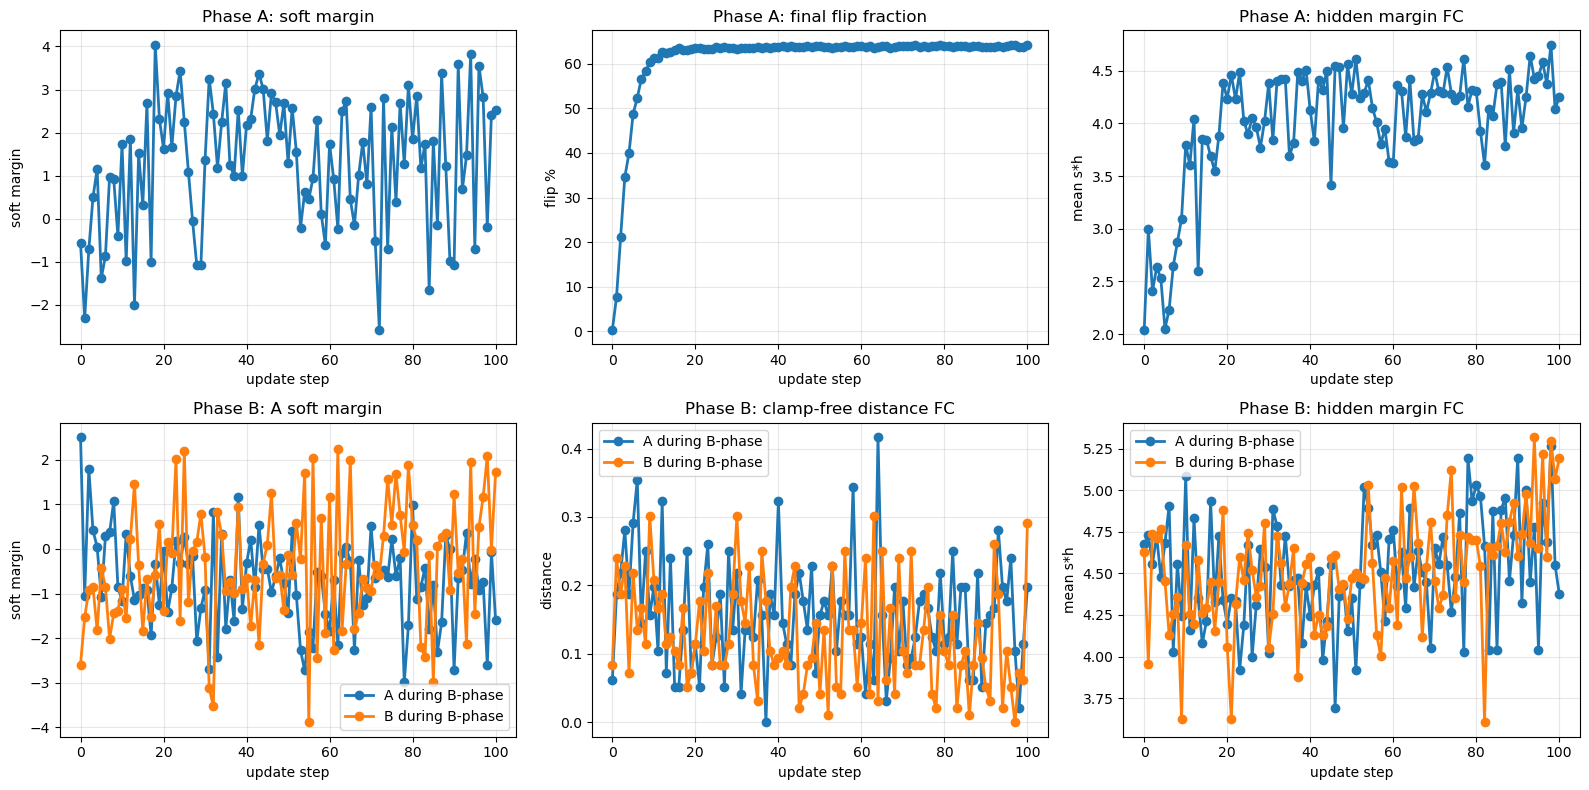

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

plot_traj(
    summary["phase_a_soft_margin_mean_traj"],
    title="Phase A: soft margin",
    ylabel="soft margin",
    ax=axes[0, 0]
)

plot_traj(
    summary["phase_a_flip_last_mean_traj"],
    title="Phase A: final flip fraction",
    ylabel="flip %",
    ax=axes[0, 1]
)

plot_traj(
    summary["phase_a_hidden_margin_fc_mean_traj"],
    title="Phase A: hidden margin FC",
    ylabel="mean s*h",
    ax=axes[0, 2]
)

plot_traj(
    summary["phase_b_a_soft_margin_mean_traj"],
    label="A during B-phase",
    title="Phase B: A soft margin",
    ylabel="soft margin",
    ax=axes[1, 0]
)
plot_traj(
    summary["phase_b_b_soft_margin_mean_traj"],
    label="B during B-phase",
    ax=axes[1, 0]
)

plot_traj(
    summary["phase_b_a_clamp_free_fc_mean_traj"],
    label="A during B-phase",
    title="Phase B: clamp-free distance FC",
    ylabel="distance",
    ax=axes[1, 1]
)
plot_traj(
    summary["phase_b_b_clamp_free_fc_mean_traj"],
    label="B during B-phase",
    ax=axes[1, 1]
)

plot_traj(
    summary["phase_b_a_hidden_margin_fc_mean_traj"],
    label="A during B-phase",
    title="Phase B: hidden margin FC",
    ylabel="mean s*h",
    ax=axes[1, 2]
)
plot_traj(
    summary["phase_b_b_hidden_margin_fc_mean_traj"],
    label="B during B-phase",
    ax=axes[1, 2]
)

plt.tight_layout()
plt.show()